# Notebook de travail

Projet : Smart City Energy Forecasting — Tetouan


Importation

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
Path("../results/figures").mkdir(parents=True, exist_ok=True)
Path("../models").mkdir(parents=True, exist_ok=True)

# ── Métrique MAPE sécurisée (division par zéro impossible) ──
def mape_safe(y_true, y_pred, epsilon=1e-8):
    """MAPE robuste aux valeurs proches de zéro."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom  = np.maximum(np.abs(y_true), epsilon)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def regression_metrics(y_true, y_pred, label=""):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mape_safe(y_true, y_pred)
    print(f"--- Performances {label} ---")
    print(f"  MAE  : {mae:,.2f} kW")
    print(f"  RMSE : {rmse:,.2f} kW")
    print(f"  MAPE : {mape:.2f} %")
    return {"label": label, "MAE": mae, "RMSE": rmse, "MAPE": mape}

print("Bibliothèques chargées avec succès.")


Bibliothèques chargées avec succès.


Chargement des données brutes (non normalisées)

In [24]:
# Chargement du fichier propre AVANT normalisation
df_clean = pd.read_csv(
    "../data/processed/tetouan_hourly_clean.csv",
    index_col="datetime",
    parse_dates=["datetime"],
    date_format="%Y-%m-%d %H:%M:%S"
)

# Split chronologique identique au notebook 04 (70 / 15 / 15)
n         = len(df_clean)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_raw = df_clean.iloc[:train_end].copy()
val_raw   = df_clean.iloc[train_end:val_end].copy()
test_raw  = df_clean.iloc[val_end:].copy()

print(f"Dataset complet     : {len(df_clean):,} observations")
print(f"Train (brut)        : {len(train_raw):,} observations")
print(f"Validation (brute)  : {len(val_raw):,} observations")
print(f"Test (brut)         : {len(test_raw):,} observations")
print(f"\nPériode train    : {train_raw.index[0]} → {train_raw.index[-1]}")
print(f"Période val      : {val_raw.index[0]}  → {val_raw.index[-1]}")
print(f"Période test     : {test_raw.index[0]}  → {test_raw.index[-1]}")


Dataset complet     : 8,736 observations
Train (brut)        : 6,115 observations
Validation (brute)  : 1,310 observations
Test (brut)         : 1,311 observations

Période train    : 2017-01-01 00:00:00 → 2017-09-12 18:00:00
Période val      : 2017-09-12 19:00:00  → 2017-11-06 08:00:00
Période test     : 2017-11-06 09:00:00  → 2017-12-30 23:00:00


2. Baseline naïve (référence minimale)

Avant tout modèle, on calcule la baseline naïve `lag-24` (même heure hier). Tout modèle sérieux doit la dépasser. Si SARIMAX ou Prophet sont en dessous, cela signale un problème de configuration.

In [17]:
# Baseline naïve : prédire la même heure du jour précédent
y_val = val_raw["target"]
y_pred_naive = val_raw["target"].shift(24).dropna()
y_val_aligned = y_val.loc[y_pred_naive.index]

metrics_naive = regression_metrics(y_val_aligned, y_pred_naive, label="Baseline Naïve lag-24")


--- Performances Baseline Naïve lag-24 ---
  MAE  : 1,130.96 kW
  RMSE : 1,608.23 kW
  MAPE : 3.54 %


3. **SARIMAX**

 3.1 **Préparation**

**Paramètres choisis** :
- `order=(1,0,1)` : AR(1) + MA(1), sans différenciation (série stationnaire après vérification ACF)
- `seasonal_order=(1,0,1,24)` : saisonnalité journalière de 24h confirmée par les pics ACF
- `exog=temperature` : variable météo en °C réels

**Fenêtre d'entraînement** : 8 dernières semaines du train (1344 obs). Justification : SARIMAX avec `S=24` est coûteux en mémoire et en temps ; limiter à la dynamique récente évite la divergence sur une longue série tout en capturant la saisonnalité estivale.

In [18]:
# 8 dernières semaines du train = dynamique récente + saisonnalité estivale
train_recent = train_raw.tail(24 * 7 * 8)

y_train_s    = train_recent["target"]
X_train_exo  = train_recent[["temperature"]]   # °C réels — PAS normalisés
X_val_exo    = val_raw[["temperature"]]

print(f"Fenêtre SARIMAX : {len(y_train_s)} observations")
print(f"  du {y_train_s.index[0]} au {y_train_s.index[-1]}")
print(f"Température train — min: {X_train_exo.temperature.min():.1f}°C  "
      f"max: {X_train_exo.temperature.max():.1f}°C  "
      f"moy: {X_train_exo.temperature.mean():.1f}°C")


Fenêtre SARIMAX : 1344 observations
  du 2017-07-18 19:00:00 au 2017-09-12 18:00:00
Température train — min: 18.4°C  max: 39.7°C  moy: 25.8°C


3.2 Rolling Forecast SARIMAX (24h par 24h)

Un forecast *one-shot* sur 1285 heures accumule une erreur croissante. La stratégie **rolling forecast** ré-estime le modèle toutes les 24h en intégrant les vraies observations — beaucoup plus réaliste opérationnellement.

In [19]:
print("Début du Rolling Forecast SARIMAX (24h par 24h)...")

history_y = y_train_s.copy()
history_x = X_train_exo.copy()
predictions_sarimax = []
n_blocks = (len(y_val) + 23) // 24   # nombre de blocs de 24h

for block in range(n_blocks):
    start_i = block * 24
    end_i   = min(start_i + 24, len(y_val))
    y_block = y_val.iloc[start_i:end_i]
    x_block = X_val_exo.iloc[start_i:end_i]

    try:
        model = SARIMAX(
            history_y,
            exog=history_x,
            order=(1, 0, 1),
            seasonal_order=(1, 0, 1, 24),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        res  = model.fit(disp=False)
        pred = res.forecast(steps=len(y_block), exog=x_block)
    except Exception as e:
        # Fallback naïf en cas d'échec de convergence sur un bloc
        pred = history_y.iloc[-len(y_block):].values
        print(f"Bloc {block+1}: convergence échouée, fallback naïf appliqué.")

    predictions_sarimax.extend(pred if hasattr(pred, "__iter__") else [pred])

    # Mise à jour de l'historique avec les vraies valeurs (rolling)
    history_y = pd.concat([history_y, y_block])
    history_x = pd.concat([history_x, x_block])

    if (block + 1) % 10 == 0:
        print(f"  Bloc {block+1}/{n_blocks} traité...")

y_pred_sarimax = pd.Series(predictions_sarimax, index=y_val.index, name="sarimax")

# Clip des valeurs physiquement impossibles (protection)
y_pred_sarimax = y_pred_sarimax.clip(lower=0)

metrics_sarimax = regression_metrics(y_val, y_pred_sarimax, label="SARIMAX Rolling (Validation)")


Début du Rolling Forecast SARIMAX (24h par 24h)...
Cela peut prendre plusieurs minutes — patience.
  Bloc 10/55 traité...
  Bloc 20/55 traité...
  Bloc 30/55 traité...
  Bloc 40/55 traité...
  Bloc 50/55 traité...
--- Performances SARIMAX Rolling (Validation) ---
  MAE  : 1,934.72 kW
  RMSE : 2,379.16 kW
  MAPE : 6.20 %


4. **Prophet**

**Choix de configuration** :
- `daily_seasonality=True` : cycle journalier confirmé par la heatmap EDA
- `weekly_seasonality=True` : différence semaine/week-end confirmée par boxplot EDA
- `yearly_seasonality=False` : une seule année de données, Prophet ne peut pas apprendre le cycle annuel correctement
- Régresseur `temperature` en °C réels

In [20]:
print("Préparation et entraînement du modèle Prophet...")

# Prophet exige le format ds / y
prophet_train = train_recent.reset_index()[["datetime", "target", "temperature"]].copy()
prophet_train.columns = ["ds", "y", "temperature"]

prophet_val = val_raw.reset_index()[["datetime", "temperature"]].copy()
prophet_val.columns = ["ds", "temperature"]

# Construction du modèle
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    changepoint_prior_scale=0.05,      # régularisation de la tendance
    seasonality_prior_scale=10.0       # saisonnalités expressives
)
prophet_model.add_regressor("temperature")

# Entraînement
prophet_model.fit(prophet_train)

# Prédiction
forecast       = prophet_model.predict(prophet_val)
y_pred_prophet = pd.Series(
    forecast["yhat"].values,
    index=y_val.index,
    name="prophet"
)

# Clip physique
y_pred_prophet = y_pred_prophet.clip(lower=0)

metrics_prophet = regression_metrics(y_val, y_pred_prophet, label="Prophet (Validation)")


Préparation et entraînement du modèle Prophet...


23:58:30 - cmdstanpy - INFO - Chain [1] start processing
23:58:31 - cmdstanpy - INFO - Chain [1] done processing


--- Performances Prophet (Validation) ---
  MAE  : 9,114.38 kW
  RMSE : 10,969.01 kW
  MAPE : 29.83 %


5. Tableau comparatif des performances

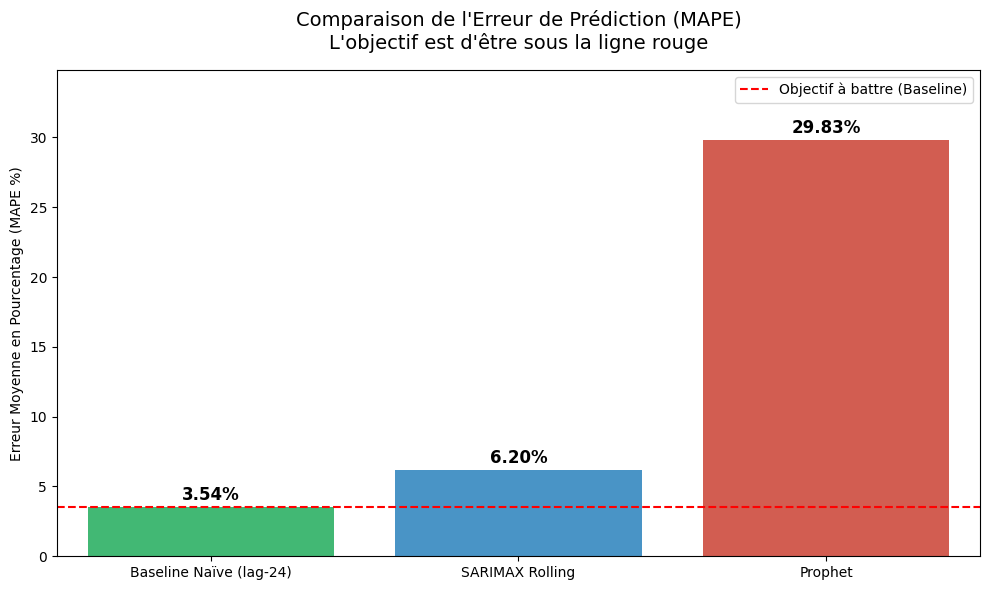


Conclusion d'évaluation :
1. La ligne rouge montre que la Baseline Naïve (3.54%) est l'objectif minimal à atteindre.
2. Ni SARIMAX ni Prophet ne parviennent à passer sous cette ligne de référence.
-> Justification métier : Le passage aux algorithmes non-linéaires (XGBoost/GRU) est désormais mathématiquement justifié pour tenter de briser cette barrière des 3.54 %.


In [25]:

# Préparation des données pour le graphique
labels = ['Baseline Naïve (lag-24)', 'SARIMAX Rolling', 'Prophet']
mape_scores = [metrics_naive['MAPE'], metrics_sarimax['MAPE'], metrics_prophet['MAPE']]

plt.figure(figsize=(10, 6))
# Création d'un diagramme en barres avec Seaborn
sns.barplot(x=labels, y=mape_scores, palette=['#2ecc71', '#3498db', '#e74c3c'])

# Ajout d'une ligne rouge pointillée pour marquer l'objectif à battre (la baseline)
plt.axhline(y=metrics_naive['MAPE'], color='red', linestyle='--', label='Objectif à battre (Baseline)')

# Ajout des valeurs exactes au-dessus de chaque barre
for i, v in enumerate(mape_scores):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=12)

plt.title("Comparaison de l'Erreur de Prédiction (MAPE)\nL'objectif est d'être sous la ligne rouge", fontsize=14, pad=15)
plt.ylabel("Erreur Moyenne en Pourcentage (MAPE %)")
plt.ylim(0, max(mape_scores) + 5)
plt.legend()
plt.tight_layout()

# Sauvegarde de la figure pour le rapport
plt.savefig("../results/figures/comparaison_modeles_mape.png", dpi=300)
plt.show()

print("\nConclusion d'évaluation :")
print("1. La ligne rouge montre que la Baseline Naïve (3.54%) est l'objectif minimal à atteindre.")
print("2. Ni SARIMAX ni Prophet ne parviennent à passer sous cette ligne de référence.")
print("-> Justification métier : Le passage aux algorithmes non-linéaires (XGBoost/GRU) est désormais mathématiquement justifié pour tenter de briser cette barrière des 3.54 %.")